<a href="https://colab.research.google.com/github/atharvsalokhe30/GenAI_Project_Practice-/blob/main/CNN_for_CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import required library

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# load cifar10 datset (60k color images)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2184s 13us/step


In [ ]:
# Normalize pixel values to range [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
# one-hot encoding labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [ ]:
# class labels for visualization
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# build a simple CNN use sequential API
model = Sequential([
    # first convolutional layer + max pooling
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    # second
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    # third convolutional layer
    Conv2D(64, (3, 3), activation='relu'),
    # flatten And add dense layer
    Flatten(),
    # fully connected layers
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')   #output layer for 10 classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compile the cnn model
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
# print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train the cnn model
history = model.fit(x_train, y_train_cat,
                    epochs = 10,
                    batch_size=64,
                    validation_data = (x_test, y_test_cat))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 85ms/step - accuracy: 0.4085 - loss: 1.6137 - val_accuracy: 0.5047 - val_loss: 1.3739
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.5554 - loss: 1.2533 - val_accuracy: 0.5906 - val_loss: 1.1541
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 80ms/step - accuracy: 0.6146 - loss: 1.0986 - val_accuracy: 0.6138 - val_loss: 1.0940
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 81ms/step - accuracy: 0.6462 - loss: 1.0061 - val_accuracy: 0.6509 - val_loss: 0.9880
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 79ms/step - accuracy: 0.6718 - loss: 0.9283 - val_accuracy: 0.6726 - val_loss: 0.9458
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.6947 - loss: 0.8734 - val_accuracy: 0.6818 - val_loss: 0.9282
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 81ms/step - accuracy: 0.7128 - loss: 0.8189 - val_accuracy: 0.6923 - val_loss: 0.8908
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.7276 - loss: 0.7811 - 

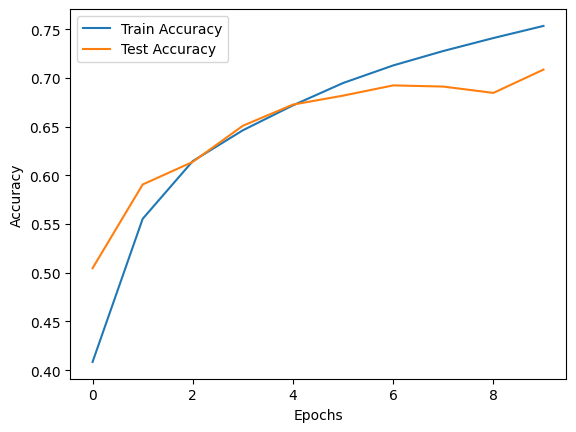

In [ ]:
# plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
#evaluate the model on test data
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print(f"\n Final Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7085 - loss: 0.8637

 Final Test Accuracy: 0.7085


In [ ]:
#predict labels for test set
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


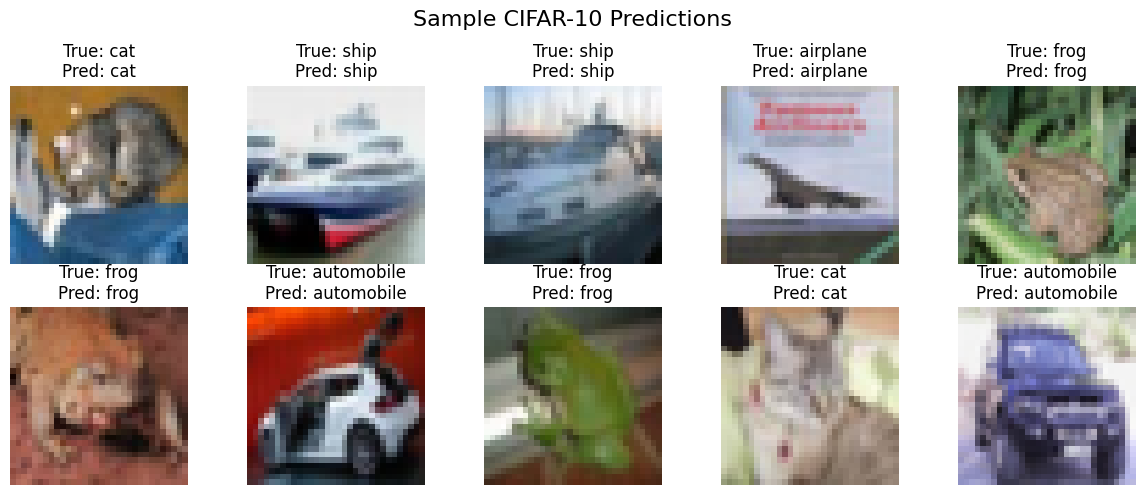

In [ ]:
# Show 10 sample predictions with images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i])
    true_label = class_names[y_test[i][0]]
    pred_label = class_names[predicted_labels[i]]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Predictions", fontsize=16)
plt.tight_layout()
plt.show()